In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

In [2]:
with open('names.txt', 'r') as f:
    names = f.read().splitlines()
    chars = sorted(set((char for name in names for char in name)))

In [3]:
CHAR_SEP = '.'

In [4]:
SEQ_SIZE = 3
VOC_SIZE = 27
EMB_SIZE = 10
HID_SIZE = 200
BCH_SIZE = 128

In [5]:
i2c    = {i: c for i, c in enumerate(chars, 1)}
i2c[0] = CHAR_SEP
c2i    = {c: i for i, c in i2c.items()}

In [6]:
def get_dataset(sequence_size: int = 3, verbose=True):
    xs = []
    ys = []
    
    for i, name in enumerate(names):
        if verbose:
            print(f"name[{i}]: {name}")
        name += CHAR_SEP
        x = ''.join([CHAR_SEP] * SEQ_SIZE)
        for j in range(len(name)):
            y = name[j]
            xs.append([c2i[c] for c in x])
            ys.append(c2i[y])
            if verbose:
                print(f"{x} -> {y}")
            x = f"{x[1:]}{name[j]}"
    
    return torch.tensor(xs), torch.tensor(ys)

xs, ys = get_dataset(SEQ_SIZE, verbose=False)
xs.shape

torch.Size([228146, 3])

In [7]:
def split_dataset(xs, ys, tr=0.8, vl=0.1, ts=0.1):
    assert len(xs) == len(ys)
    assert abs(tr + vl + ts - 1.0) < 1e-6

    n = len(xs)

    n_tr = int(tr * n)
    n_vl = int(vl * n)

    xs_tr = xs[:n_tr]
    ys_tr = ys[:n_tr]

    xs_vl = xs[n_tr:n_tr + n_vl]
    ys_vl = ys[n_tr:n_tr + n_vl]

    xs_ts = xs[n_tr + n_vl:]
    ys_ts = ys[n_tr + n_vl:]

    return xs_tr, ys_tr, xs_vl, ys_vl, xs_ts, ys_ts

In [8]:
(
    xs_tr, ys_tr,
    xs_vl, ys_vl,
    xs_ts, ys_ts
) = split_dataset(xs, ys)

In [9]:
xs_tr.shape, xs_vl.shape, xs_ts.shape

(torch.Size([182516, 3]), torch.Size([22814, 3]), torch.Size([22816, 3]))

In [10]:
xs_tr.shape[0] + xs_vl.shape[0] + xs_ts.shape[0] == xs.shape[0]

True

#### Architecture

In [11]:
g = torch.Generator()
g.manual_seed(1777213731)

In [12]:
import functools
import operator

C = torch.randn((VOC_SIZE, EMB_SIZE), dtype=torch.float32, generator=g)
C.requires_grad = True

W1 = torch.randn((SEQ_SIZE * EMB_SIZE, HID_SIZE), dtype=torch.float32, generator=g)
W1.requires_grad = True
b1 = torch.randn(HID_SIZE, dtype=torch.float32, generator=g)
b1.requires_grad = True

W2 = torch.randn((HID_SIZE, VOC_SIZE), dtype=torch.float32, generator=g)
W2.requires_grad = True
b2 = torch.randn(VOC_SIZE, dtype=torch.float32, generator=g)
b2.requires_grad = True

parameters = [C, W1, b1, W2, b2]

total = sum((
    functools.reduce(operator.mul, p.shape)
    for p in parameters
))
total

11897

In [13]:
def forward(xs):
    X_emb   = C[xs]
    h       = (X_emb.view(-1, SEQ_SIZE * EMB_SIZE) @ W1 + b1).tanh()
    logits  = h.view(-1, HID_SIZE) @ W2 + b2
    return logits

#### Training

In [14]:
loss_tr = []
loss_vl = []

In [15]:
epochs = 5000
log_every = 500

lrs = torch.linspace(1, 0, epochs)

for epoch in range(epochs):
    # mini batch
    batch = torch.randint(0, xs_tr.shape[0], (BCH_SIZE,))
    
    # forward pass
    logits = forward(xs_tr[batch])
    loss   = F.cross_entropy(logits, ys_tr[batch])
    
    # backward pass
    for parameter in parameters:
        parameter.grad = None
    loss.backward()
    
    # optimize
    lr = lrs[epoch]
    for parameter in parameters:
        parameter.data += -lr * parameter.grad

    loss_tr.append((epoch, loss.item()))
    
    # validate
    if epoch % log_every == 0:
        print(f"epoch[{epoch}] = {loss.item()}")

        with torch.no_grad():
            logits = forward(xs_vl)
            loss   = F.cross_entropy(logits, ys_vl)
            loss_vl.append((epoch, loss.item()))

logits = forward(xs_ts)
loss   = F.cross_entropy(logits, ys_ts)
loss

epoch[0] = 26.71383285522461
epoch[500] = 4.650824069976807
epoch[1000] = 5.367095947265625
epoch[1500] = 3.44882869720459
epoch[2000] = 4.194281578063965
epoch[2500] = 3.0241763591766357
epoch[3000] = 2.549359083175659
epoch[3500] = 2.592728853225708
epoch[4000] = 2.0734996795654297
epoch[4500] = 2.0485267639160156


tensor(2.5411, grad_fn=<NllLossBackward0>)

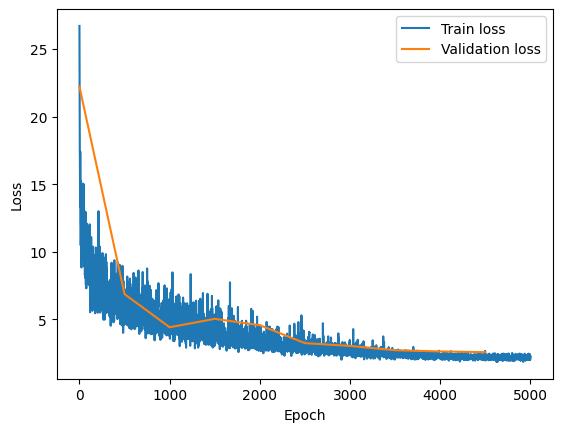

In [16]:
import numpy as np

epochs_tr = [e for e, l in loss_tr]
losses_tr = [l for e, l in loss_tr]

epochs_vl = [e for e, l in loss_vl]
losses_vl = [l for e, l in loss_vl]
    
plt.plot(epochs_tr, losses_tr, label="Train loss")
plt.plot(epochs_vl, losses_vl, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

#### Inference

In [ ]:
gen_names = []
for _ in range(10):
    gen_name = ''.join([CHAR_SEP] * SEQ_SIZE)
    while True:
        xs = torch.tensor([c2i[c] for c in gen_name[-SEQ_SIZE:]])
        logits = forward(xs)
        probs  = torch.softmax(logits, dim=1)
        i      = torch.multinomial(probs, 1,  replacement=True, generator=g).item()
        c      = i2c[i]
        if c == CHAR_SEP:
            gen_names.append(gen_name[SEQ_SIZE:])
            break
        gen_name += c
gen_names

['kaxlee',
 'kharo',
 'tere',
 'tegh',
 'ever',
 'lole',
 'sainah',
 'raeristephyri',
 'syn',
 'eca']

#### Evaluation

In [18]:
nll = 0.0
count = 0
for name in names:
    xt = ''.join([CHAR_SEP] * SEQ_SIZE)
    for c in name:
        x = torch.tensor([c2i[c] for c in xt])
        y = torch.tensor([c2i[c]])
        logits = forward(x)
        nll   += F.cross_entropy(logits, y)
        count += 1
        xt = f"{xt[1:]}{c}"
nll / count

tensor(2.4042, grad_fn=<DivBackward0>)